# 01 - Data Exploration

Explore the sports-impact metadata, class balance, feature relationships, and a few sampled video frames.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.metadata import LABEL_ORDER, load_metadata
from src.data.video import sample_video_frames

sns.set_theme(style='whitegrid')

In [2]:
df = load_metadata(ROOT / 'data/metadata.csv', ROOT / 'data/cv_module_videos')
df.head()

,video_id,sport,impact_type,body_region,player_down,risk_level,video_path,label_id
0,VID_001,hockey,object_hit,head_face,yes,high,/Users/abigailreynolds/Desktop/AIPI_MEng/AIPI_...,2
1,VID_002,hockey,collision,upper_body,yes,moderate,/Users/abigailreynolds/Desktop/AIPI_MEng/AIPI_...,1
2,VID_003,hockey,collision,upper_body,yes,moderate,/Users/abigailreynolds/Desktop/AIPI_MEng/AIPI_...,1
3,VID_004,hockey,object_hit,head_face,yes,high,/Users/abigailreynolds/Desktop/AIPI_MEng/AIPI_...,2
4,VID_005,hockey,object_hit,head_face,yes,high,/Users/abigailreynolds/Desktop/AIPI_MEng/AIPI_...,2


In [3]:
df.shape, df['risk_level'].value_counts().reindex(LABEL_ORDER)

((172, 8),
 risk_level
 low         64
 moderate    64
 high        44
 Name: count, dtype: int64)

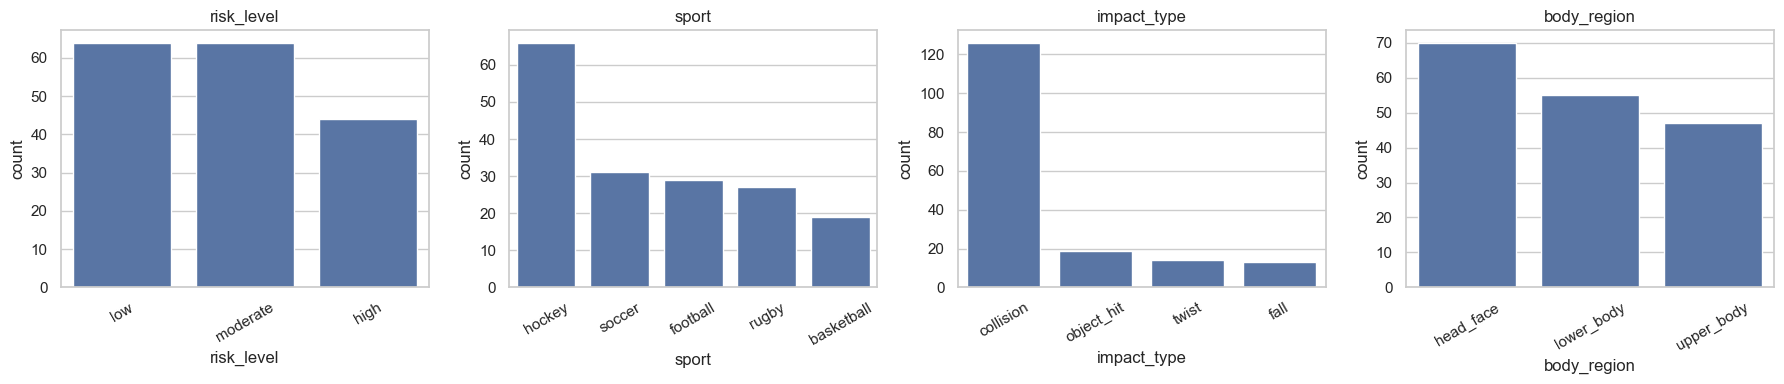

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['risk_level', 'sport', 'impact_type', 'body_region']):
    order = LABEL_ORDER if col == 'risk_level' else df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
fig.tight_layout()

In [5]:
for col in ['sport', 'impact_type', 'body_region', 'player_down']:
    display(pd.crosstab(df[col], df['risk_level'], normalize='index')[LABEL_ORDER].round(3))

risk_level,low,moderate,high
sport,,,
basketball,0.526,0.316,0.158
football,0.448,0.379,0.172
hockey,0.348,0.242,0.409
rugby,0.370,0.556,0.074
soccer,0.258,0.516,0.226


risk_level,low,moderate,high
impact_type,,,
collision,0.381,0.373,0.246
fall,0.308,0.462,0.231
object_hit,0.263,0.316,0.421
twist,0.500,0.357,0.143


risk_level,low,moderate,high
body_region,,,
head_face,0.129,0.357,0.514
lower_body,0.400,0.455,0.145
upper_body,0.702,0.298,0.000


risk_level,low,moderate,high
player_down,,,
no,0.861,0.139,0.000
yes,0.243,0.434,0.324


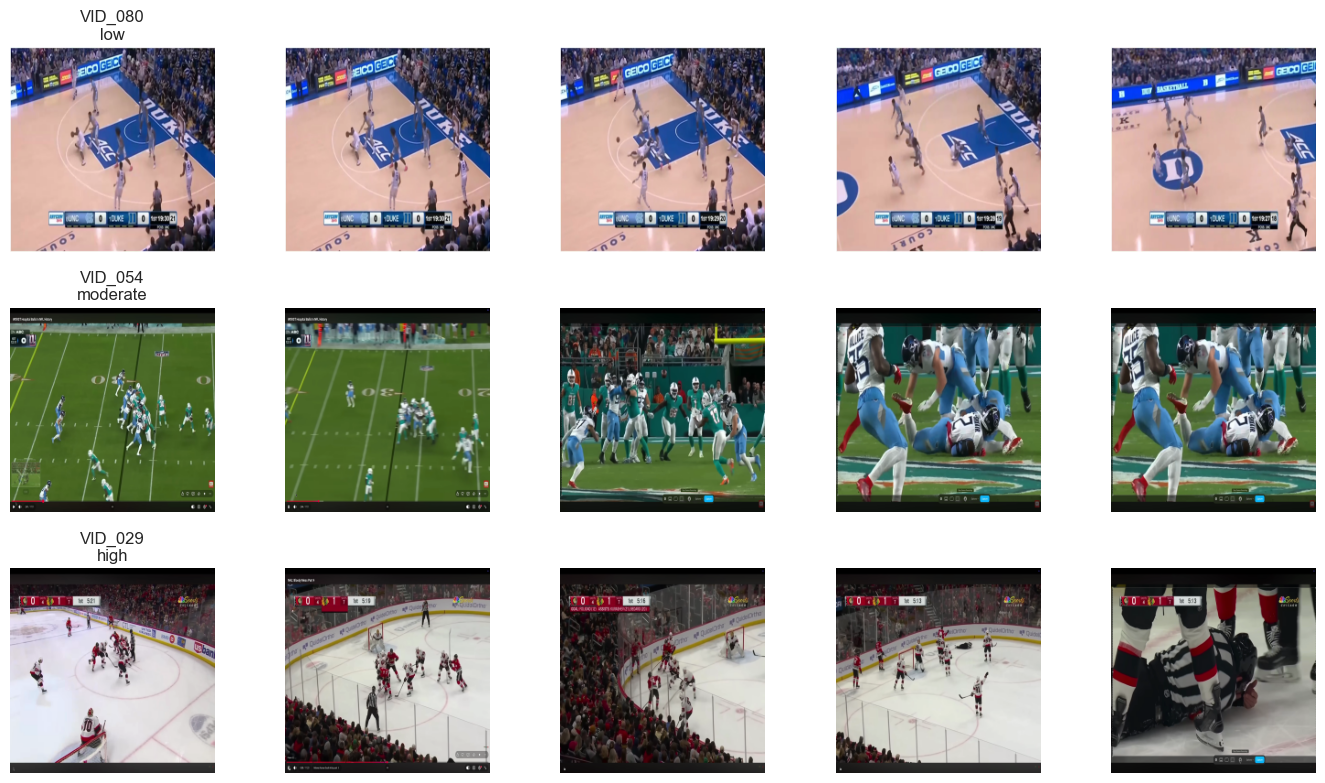

In [6]:
sample = pd.concat([
    df[df['risk_level'] == label].sample(1, random_state=7)
    for label in LABEL_ORDER
]).reset_index(drop=True)
fig, axes = plt.subplots(len(sample), 5, figsize=(14, 8))
for row_idx, row in sample.iterrows():
    frames = sample_video_frames(row['video_path'], num_frames=5, resize=(224, 224), rgb=True)
    for col_idx, frame in enumerate(frames):
        ax = axes[row_idx, col_idx]
        ax.imshow(frame)
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(f"{row['video_id']}\n{row['risk_level']}")
fig.tight_layout()

## Video Duration

Measure clip lengths from the video files to understand the temporal range represented in the dataset.

In [7]:
import cv2

video_rows = []
for path in sorted((ROOT / 'data/cv_module_videos').iterdir()):
    if path.suffix.lower() not in {'.mov', '.mp4', '.avi', '.mkv', '.m4v'}:
        continue
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    duration_seconds = frame_count / fps if fps and fps > 0 else None
    video_rows.append({
        'video_id': path.stem.upper(),
        'filename': path.name,
        'fps': fps,
        'frame_count': frame_count,
        'duration_seconds': duration_seconds,
    })

video_lengths = pd.DataFrame(video_rows)
video_lengths['duration_seconds'].describe()

count    172.000000
mean       9.621599
std        5.088529
min        1.973633
25%        5.949167
50%        8.945833
75%       11.825308
max       35.958333
Name: duration_seconds, dtype: float64

In [8]:
display(video_lengths.sort_values('duration_seconds').head(10))
display(video_lengths.sort_values('duration_seconds', ascending=False).head(10))

,video_id,filename,fps,frame_count,duration_seconds
114,VID_116,VID_116.mp4,30.400784,60.0,1.973633
108,VID_110,VID_110.mp4,30.171475,60.0,1.988633
111,VID_113,VID_113.mp4,30.440709,67.0,2.201000
112,VID_114,VID_114.mp4,30.192972,69.0,2.285300
121,VID_123,VID_123.mp4,30.000000,70.0,2.333333
105,VID_107,VID_107.mp4,30.385598,71.0,2.336633
171,VID_102,vid_102.mp4,30.019380,79.0,2.631633
92,VID_093,VID_093.mp4,30.485473,93.0,3.050633
76,VID_077,VID_077.mp4,30.060421,100.0,3.326633
107,VID_109,VID_109.mp4,30.152225,103.0,3.416000


,video_id,filename,fps,frame_count,duration_seconds
8,VID_009,VID_009.mov,41.687138,1499.0,35.958333
18,VID_019,VID_019.mov,54.813830,1374.0,25.066667
128,VID_130,VID_130.mp4,30.040067,728.0,24.234300
33,VID_034,VID_034.mov,55.330189,1173.0,21.200000
27,VID_028,VID_028.mov,57.422152,1214.0,21.141667
131,VID_133,VID_133.mp4,30.023459,590.0,19.651300
4,VID_005,VID_005.mov,55.476603,1067.0,19.233333
129,VID_131,VID_131.mp4,30.037943,570.0,18.976000
32,VID_033,VID_033.mov,56.946277,1007.0,17.683333
3,VID_004,VID_004.mov,41.645390,734.0,17.625000


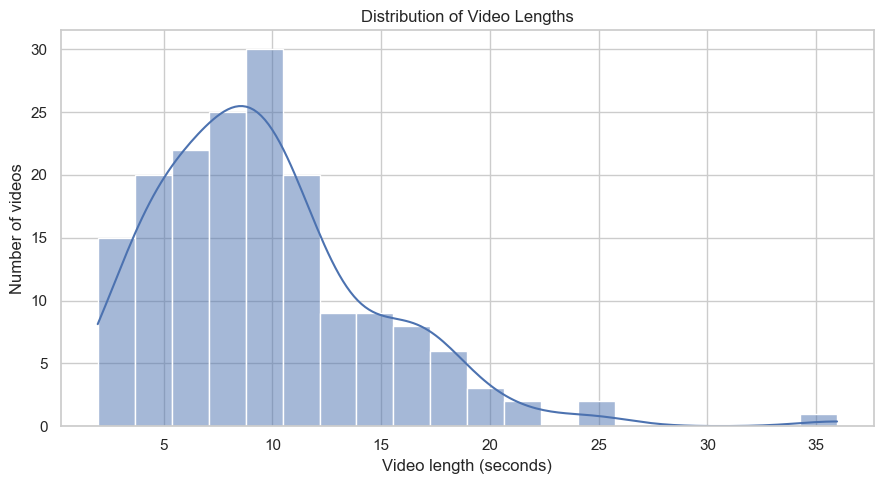

In [9]:
plt.figure(figsize=(9, 5))
sns.histplot(video_lengths['duration_seconds'], bins=20, kde=True)
plt.xlabel('Video length (seconds)')
plt.ylabel('Number of videos')
plt.title('Distribution of Video Lengths')
plt.tight_layout()